<a href="https://colab.research.google.com/github/Subroy1/MSAI_AllPracticeModules/blob/main/Module%209/Assignment9_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Required Assignment 9.2: A First Look at the Ridge Regression Model

**Expected Time: 45 Minutes**

**Total Points: 30**

This assignment introduces the `Ridge` regression estimator from scikit-learn.  You will revisit the insurance data from the previous assignment and experiment with varying the `alpha` parameter discussed in Video 9.4. Your work here is a basic introduction where complexity in the preprocessing steps will be added to scale your data.  For now, you are just to familiarize yourself with the `Ridge` regression estimator and its `alpha` parameter.

#### Index

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn import set_config
set_config(display="diagram")

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### The Data: Insurance

Below the insurance data is loaded as train and test data with the cubic polynomial features created already.  Similarly, the transformed target feature is attached.

In [ ]:
train_df = pd.read_csv('/content/sample_data/train_cubic.csv')
test_df = pd.read_csv('/content/sample_data/test_cubic.csv')

In [ ]:
train_df.head()

In [ ]:
test_df.head()

### Problem 1

#### Train and Test data

**5 Points**

Use the `train_df` and `test_df` data to split the data into `X_train`, `X_test`, `y_train` and `y_test`.

Remember that the `target_log` column is the target column for your model.



In [10]:
### GRADED
X_train, X_test, y_train, y_test = '', '', '', ''
# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_df.drop(columns = ['target_log']),test_df.drop(columns = ['target_log']), train_df['target_log'], test_df['target_log']

# Answer check
print(type(X_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


### Problem 2

#### Default `Ridge` model

**10 Points**

Now, use the `Ridge` regressor with default settings to build your first model. To this regressor, chain a `fit()` function to  train your model using `X_train` and `y_train`. Assign the result to `model_1`.

Next, assign `model_1` coefficients as an array to `model_1_coefs` below.  

In [11]:
### GRADED
model_1 = ''
model_1_coefs = ''
# YOUR CODE HERE
model_1= Ridge().fit(X_train,y_train)
model_1_coefs=  model_1.coef_

# Answer check
print(f'Ridge Coefs: {np.round(model_1_coefs, 2)}')

Ridge Coefs: [ 0.12 -0.04  0.67 -0.   -0.   -0.03  0.   -0.02  0.18  0.   -0.    0.
  0.   -0.    0.   -0.    0.   -0.   -0.02]


### Problem 3

#### Exploring different `alpha` values

**10 Points**

Below, a list of alpha values is given to you. Define a `for` loop to iterate over the list `alphas` to create and train different Ridge models.

Append the coefficients of each Ridge model as a list to `coef_list` below.  

In [13]:
alphas = [0.001, 1.0, 10.0, 100.0]

In [14]:
### GRADED
coef_list = []
# YOUR CODE HERE
for i in range (0, len(alphas)):
    ridge=Ridge(alphas[i])
    coef_list.append((ridge).fit(X_train, y_train).coef_)

# Answer check
len(coef_list)
print('For alpha = 100 we have the following coefficients:')
list(zip(X_train.columns, coef_list[-1]))

For alpha = 100 we have the following coefficients:


[('age', np.float64(0.057995560619048925)),
 ('bmi', np.float64(-0.01857277129797933)),
 ('children', np.float64(0.02488114710602535)),
 ('age^2', np.float64(-6.485822889360162e-05)),
 ('age bmi', np.float64(-0.0005377264952375008)),
 ('age children', np.float64(-0.012800295220730323)),
 ('bmi^2', np.float64(0.0019230813061400784)),
 ('bmi children', np.float64(0.01781247746232503)),
 ('children^2', np.float64(0.07550312112716857)),
 ('age^3', np.float64(1.2197374179731837e-06)),
 ('age^2 bmi', np.float64(-1.305801343680029e-05)),
 ('age^2 children', np.float64(0.000259911458493027)),
 ('age bmi^2', np.float64(2.48821034524388e-05)),
 ('age bmi children', np.float64(-0.0004527793675625475)),
 ('age children^2', np.float64(0.001056489373286773)),
 ('bmi^3', np.float64(-3.621089705724068e-05)),
 ('bmi^2 children', np.float64(0.0001291246679528559)),
 ('bmi children^2', np.float64(-0.0025796671557198948)),
 ('children^3', np.float64(-0.009769612804031897))]

### Problem 4

#### Exploring the coefficient for `children`

**5 Points**

To see the effect of varying alpha, you are to focus on the coefficients of the `children` feature.  Use the code `list([i[2] for i in coef_list])` to assign those values as a list to `child_coefs` below, building models on the given list of alphas.   

In general, as you increase `alpha` what happens to the value of the coefficient -- `increase`, `decrease`, or `neither`?  Assign your answer as a string to `ans4` below.


<class 'list'>
decrease
[np.float64(1.158939112186318), np.float64(0.6748664776109444), np.float64(0.15766048969333712), np.float64(0.02488114710602535)]


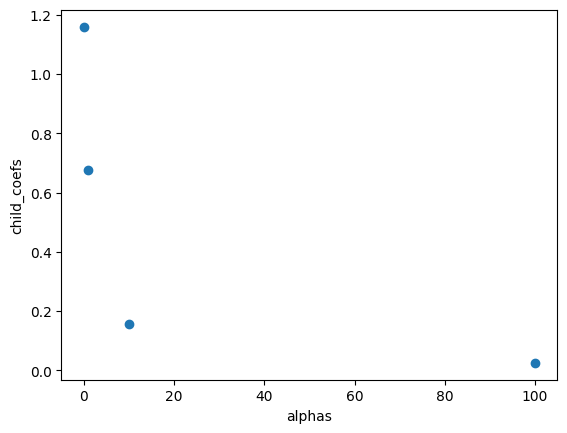

In [16]:
### GRADED
child_coefs = ''
ans4 = ''
# YOUR CODE HERE
child_coefs=[]

for i in coef_list:
    child_coefs.append(i[2])

plt.scatter(x=alphas, y=child_coefs)
plt.xlabel("alphas")
plt.ylabel("child_coefs")

ans4='decrease'
print(type(child_coefs))
print(ans4)
print(child_coefs)
